<a href="https://colab.research.google.com/github/Lindsey2507/machine-learning-journey/blob/main/exercises/Numpy_Image_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy Image Processing

## Goal
Learn basic image processing techniques using NumPy.

## Topics
- Load and inspect an image
- Display the RGB channels
- Flipping
- Cropping
- Brightness adjustment
- Convert RGB to grayscale
- Noise addition
- Concatenation

# Load Image

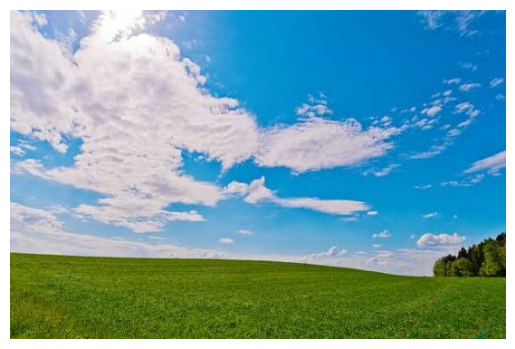

<class 'PIL.JpegImagePlugin.JpegImageFile'>
<class 'numpy.ndarray'>
(364, 548, 3)
uint8
[246 229 237]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open("sky.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()
print(type(image))

image2 = Image.open("portrait.jpg")
image2_array=np.array(image2)

image3 = Image.open("ID photo.JPG")
image3_array = np.array(image3)

image_array = np.array(image)
print(type(image_array))
print(image_array.shape)
print(image_array.dtype)
print(image_array[0,0])






# RGB channels

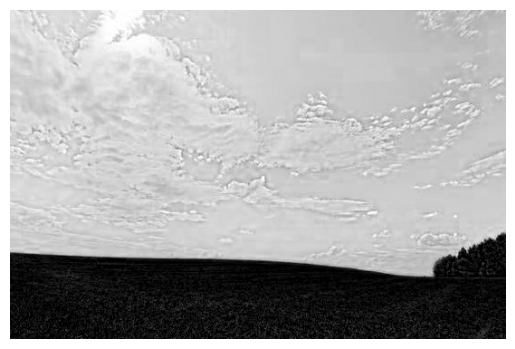

(364, 548)


In [ ]:
img_red = image_array[:,:,0]
img_green = image_array[:,:,1]
img_blue = image_array[:,:,2]

plt.imshow(img_blue, cmap="gray")
plt.axis("off")
plt.show()

print(img_blue.shape)

# Flip the image

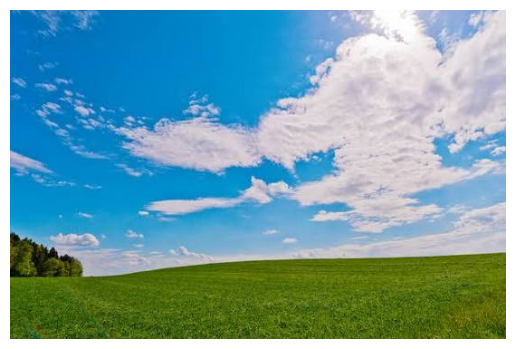

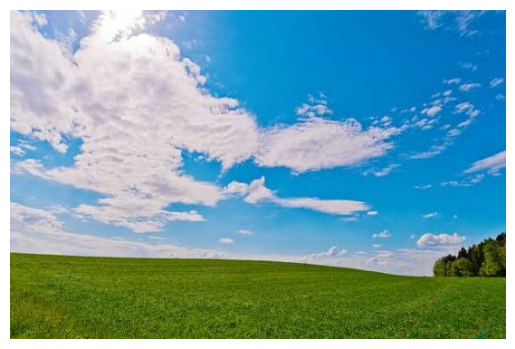

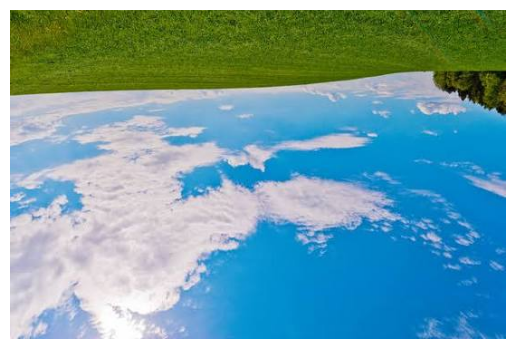

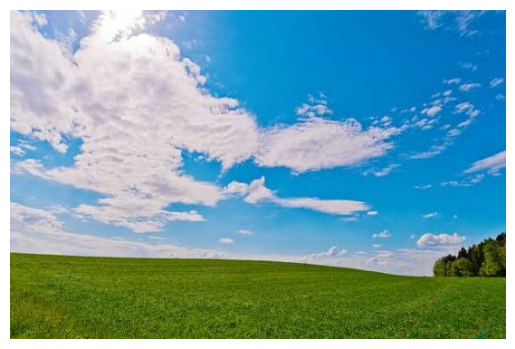

In [ ]:

#horizontal
def flip_horizontal(img_origin):
  img_hor = img_origin.copy()
  n = img_hor.shape[1]
  for i in range(n//2):
    img =img_hor[:,i].copy()
    img_hor[:,i] = img_hor[:, n-1-i]
    img_hor[:, n-1-i] = img
  return img_hor
img_flip = flip_horizontal(image_array)
plt.imshow(img_flip)
plt.axis("off")
plt.show()

plt.imshow(image_array)
plt.axis("off")
plt.show()

# vertical
def flip_vertical(img_origin):
  img_ver = img_origin.copy()
  img_ver = img_ver[::-1, :, :]
  return img_ver
img_ver = flip_vertical(image_array)
plt.imshow(img_ver)
plt.axis("off")
plt.show()







# Crop image

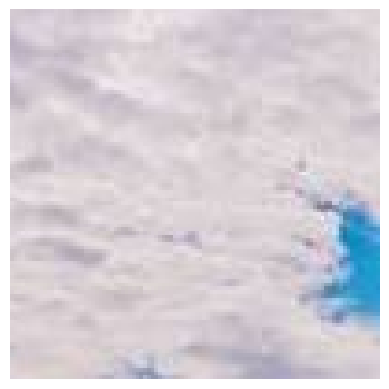

In [ ]:

def crop(img, top, left, bot, right):
  m = img.shape[0]
  n = img.shape[1]
  new_img = img[top:bot, left:right, :]
  return new_img
crop_img = crop(image_array, 100, 100, 200, 200)
plt.imshow(crop_img)
plt.axis("off")
plt.show()

# Change brightness

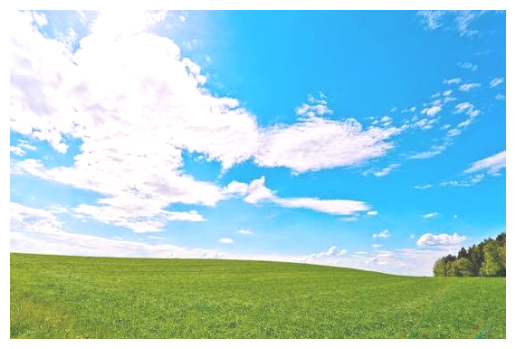

In [ ]:

def change_brightness(img, k):
  img_change = img.copy()
  img_change = img_change.astype(np.int16)
  img_change = img_change + k
  img_change = np.clip(img_change, 0, 255)
  img_change = img_change.astype(np.uint8)
  return img_change
img_bright = change_brightness(image_array, 50)
plt.imshow(img_bright)
plt.axis("off")
plt.show()

# Grayscale

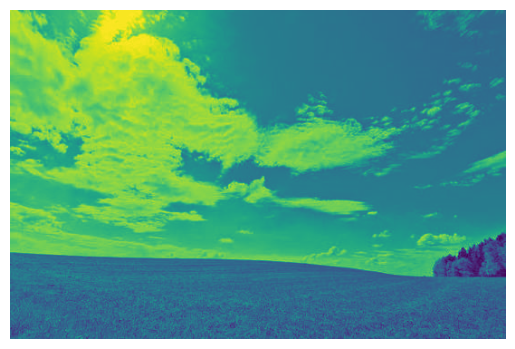

In [ ]:
def grayscale(img):
  R=img[:,:,0]
  G=img[:,:,1]
  B=img[:,:,2]
  img_gray =  0.299 * R + 0.587 * G + 0.114 * B
  return img_gray.astype(np.uint8)
img_gray = grayscale(image_array)
plt.imshow(img_gray)
plt.axis("off")
plt.show()

# Add noise

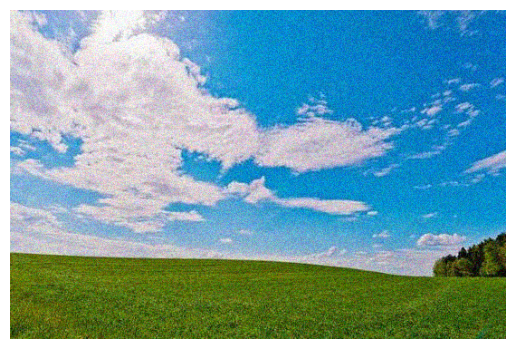

In [ ]:
def noise(img, k):
  m = img.shape[0]
  n = img.shape[1]
  rand_arr = np.random.randint(-k, k+1, size=(m,n,3))
  rand= rand_arr + img.astype(np.int16)
  rand = np.clip(rand, 0, 255)
  rand = rand.astype(np.uint8)
  return rand
random_arr = noise(image_array,30)
plt.imshow(random_arr)
plt.axis("off")
plt.show()

# Combine images

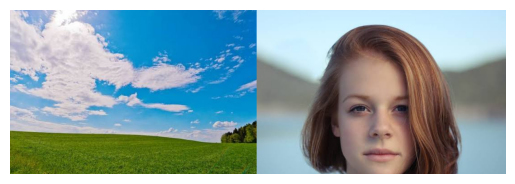

In [ ]:
def combine_hor(img1, img2):
  min_height = min(img1.shape[0], img2.shape[0])
  # min_width = np.min(img1.shape[1], img2.shape[1])
  img1_crop = crop(img1, 0, 0, min_height, img1.shape[1]-1)
  img2_crop = crop(img2, 0, 0, min_height, img2.shape[1]-1)
  new_img = np.concatenate((img1_crop, img2_crop), axis=1)
  return new_img
new = combine_hor(image_array, image2_array)
plt.imshow(new)
plt.axis("off")
plt.show()